# Lecture 6 — Class Exercise
## Part-to-Whole: Hierarchical Visualization

> **Push to:** `week06/lecture06_exercise.ipynb`

**Rules:**
1. Use `px` first, then customise with `update_traces` / `update_layout`
2. Colour encodes a meaningful category — not decoration
3. Insight title names the specific finding
4. Consider: would a bar chart be clearer? If yes, use the bar chart

---


In [1]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Global Energy Mix by Country and Source
df = pd.read_csv('../data/global_energy_mix.csv')

# Source type mapping — reuse from lecture
source_category = {
    'Coal': 'Fossil', 'Oil': 'Fossil', 'Natural Gas': 'Fossil',
    'Nuclear': 'Low-carbon', 'Hydro': 'Low-carbon',
    'Wind': 'Renewable', 'Solar': 'Renewable', 'Other Renewables': 'Renewable'
}
df['Source_Type'] = df['Source'].map(source_category)

print(f"Loaded: {len(df)} rows")
print(df.head(10))


Loaded: 103 rows
         Country         Region            Source  Share_pct     TWh  \
0  United States  North America              Coal         10  1015.0   
1  United States  North America               Oil         35  3220.0   
2  United States  North America       Natural Gas         34  3083.0   
3  United States  North America           Nuclear          9   798.0   
4  United States  North America             Hydro          3   339.0   
5  United States  North America              Wind          4   413.0   
6  United States  North America             Solar          3   325.0   
7  United States  North America  Other Renewables          2   229.0   
8          China           Asia              Coal         60  7168.0   
9          China           Asia               Oil         18  1620.0   

  Source_Type  
0      Fossil  
1      Fossil  
2      Fossil  
3  Low-carbon  
4  Low-carbon  
5   Renewable  
6   Renewable  
7   Renewable  
8      Fossil  
9      Fossil  


## Task 1 — Treemap: fossil fuel dependency by country

**What to build:** A treemap showing **fossil fuel TWh only**, broken down by Region → Country → Source (Coal / Oil / Natural Gas).

**Requirements:**
- Filter to fossil sources only before plotting
- Use `path=['Region', 'Country', 'Source']` for the hierarchy
- Colour encodes the fossil source type (Coal / Oil / Natural Gas) with a CVD-safe palette
- Show TWh values in labels — no percentages
- Grey out parent nodes (Region and Country level)
- Insight title naming which region or country is most fossil-dependent

> 💡 `df.loc[df['Source_Type'] == 'Fossil']`


Fossil rows: 43
['Coal' 'Oil' 'Natural Gas']
Region
Asia             35284.0
Europe           15387.0
Latin America    12376.0
North America    11131.0
Middle East       9671.0
Africa            8620.0
Oceania           8142.0
Name: TWh, dtype: float64


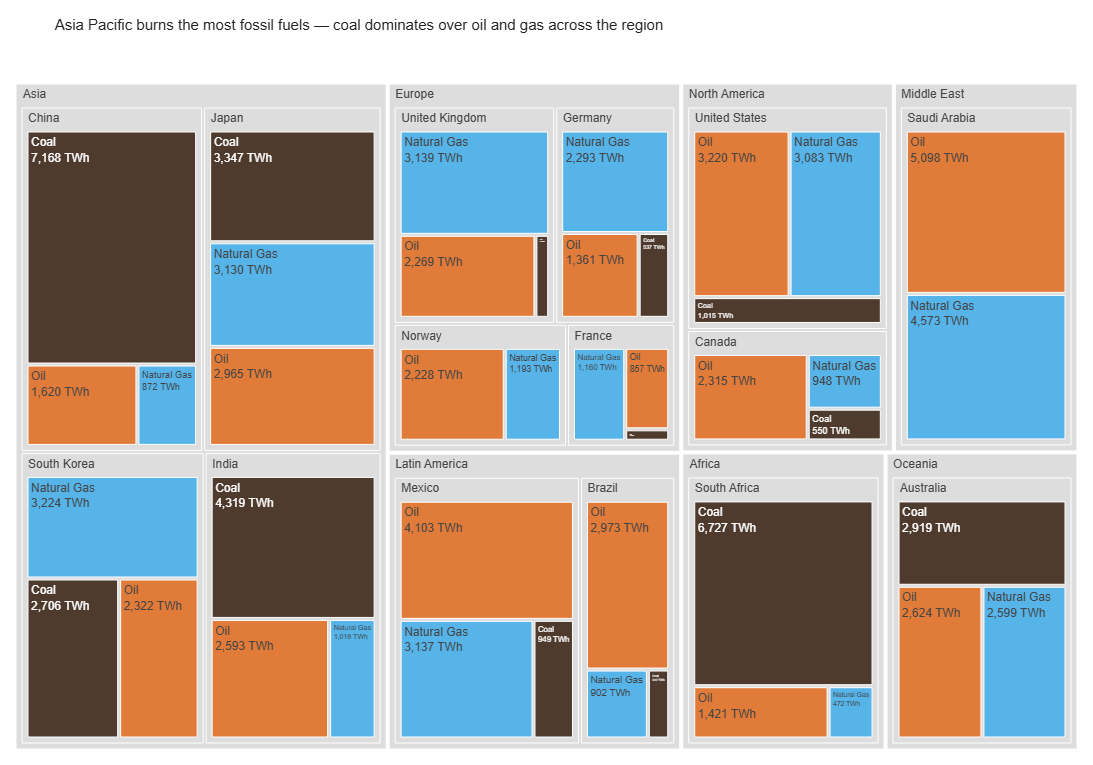

In [10]:
# Task 1

fossil = df.loc[df['Source_Type'] == 'Fossil'].copy()

print(f"Fossil rows: {len(fossil)}")
print(fossil['Source'].unique())
print(fossil.groupby('Region')['TWh'].sum().sort_values(ascending=False))


# Step 2: Define CVD-safe colour palette for the three fossil sources
# Using a palette safe for deuteranopia/protanopia (the most common forms):
#   Coal        → dark charcoal/brown  (distinguishable by lightness)
#   Oil         → orange               (CVD-safe warm tone)
#   Natural Gas → sky blue             (CVD-safe cool tone, distinct from orange)

fossil_color_map = {
    'Coal':        '#4E3B2E',   # dark brown/charcoal — heaviest emitter
    'Oil':         '#E07B39',   # orange — CVD-safe warm
    'Natural Gas': '#56B4E9',   # sky blue — CVD-safe cool (from Wong palette)
}

# ── Step 3: Plotly Express base chart ─────────────────────────────────────────
fig = px.treemap(
    fossil,
    path=['Region', 'Country', 'Source'],   # Region → Country → Fossil Source
    values='TWh',
    color='Source',                          # colour encodes fossil source type
    color_discrete_map=fossil_color_map,
    labels={'TWh': 'Energy (TWh)', 'Source': 'Fossil Source'},
    height=750, width=1300
)

# ── Step 4: Customise traces ──────────────────────────────────────────────────
fig.update_traces(
    textinfo='label+value',
    # Show TWh values — NO percentages, thousands separator, no decimals
    texttemplate='%{label}<br>%{value:,.0f} TWh',
    hovertemplate='<b>%{label}</b><br>%{value:,.0f} TWh<extra></extra>',
)

# Grey out parent nodes (Region and Country level)
# Colours list has entries for all nodes; leaf nodes get the palette colour,
# parent nodes (Region / Country) fall back to the discrete map as '#ffffff' or
# whatever Plotly assigned — we override non-leaf colours to grey.
leaf_colors = set(fossil_color_map.values())
fig.data[0].marker.colors = [
    c if c in leaf_colors else '#DDDDDD'
    for c in fig.data[0].marker.colors
]

# ── Step 5: Layout ────────────────────────────────────────────────────────────
fig.update_layout(
    title=dict(
        text=(
            'Asia Pacific burns the most fossil fuels — '
            'coal dominates over oil and gas across the region'
        ),
        font=dict(family='Arial', size=15, color='#222222')
    ),
    font=dict(family='Arial', size=12),
    margin=dict(l=10, r=10, t=60, b=10),
    paper_bgcolor='white',
)

fig.show()


## Task 2 — Sunburst: tipping behaviour by day and meal time

**What to build:** A sunburst chart using the built-in `tips` dataset showing how **total bill amount** is distributed across day → time → smoker status.

**Requirements:**
- Load tips with `px.data.tips()`
- Aggregate **total bill** (sum of `total_bill`) per group — not count
- Hierarchy: `path=['day', 'time', 'smoker']`
- Colour encodes smoker status with a CVD-safe blue/orange palette
- Grey out parent nodes (day and time level)
- Use `percent parent` for text labels
- Insight title describing where the most spending happens

> 💡 `tips.groupby(['day', 'time', 'smoker'])['total_bill'].sum().reset_index()`


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB
None
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
     day    time smoker  Total_Bill
6    Sun  Dinner     No     1168.88
5    Sat  Dinner    Yes      893.62
4    Sat  Dinner     No    

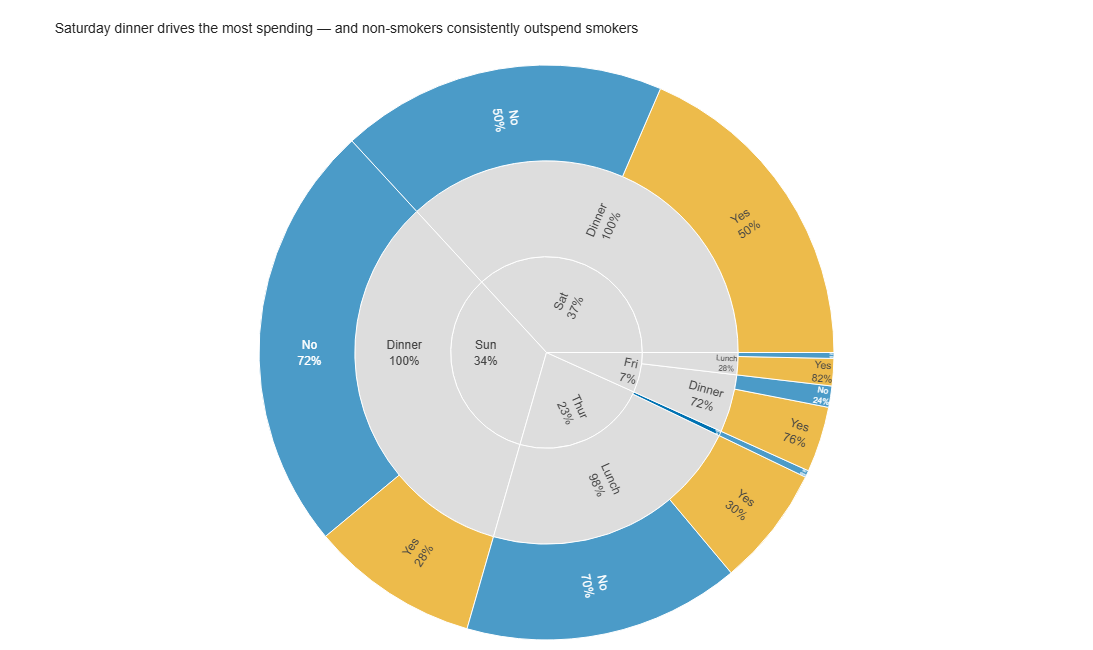

In [9]:
# Task 2
# YOUR CODE HERE

# Task 2: Sunburst — Tipping Behaviour by Day and Meal Time
# ----------------------------------------------------------

# Step 1: Load the built-in tips dataset
tips = px.data.tips()
print(tips.info())
print(tips.head())

# Step 2: Aggregate total_bill (SUM) per day / time / smoker group
df_sun = (
    tips.groupby(['day', 'time', 'smoker'])['total_bill']
    .sum()
    .reset_index()
    .rename(columns={'total_bill': 'Total_Bill'})
)

# Inspect — Saturday Dinner should be the dominant node
print(df_sun.sort_values('Total_Bill', ascending=False))


# Step 3: CVD-safe colour palette for smoker status
# 'Yes' (smoker) → orange  (Wong palette: #E69F00)
# 'No'  (non-smoker) → blue (Wong palette: #0072B2)
# Both are distinguishable under deuteranopia and protanopia

smoker_color_map = {
    'Yes': '#E69F00',   # orange — smoker
    'No':  '#0072B2',   # blue   — non-smoker
}

# ── Step 4: Plotly Express base chart ─────────────────────────────────────────
fig = px.sunburst(
    df_sun,
    path=['day', 'time', 'smoker'],
    values='Total_Bill',
    color='smoker',
    color_discrete_map=smoker_color_map,
    labels={'Total_Bill': 'Total Bill ($)', 'smoker': 'Smoker?'},
    height=650, width=650
)

# ── Step 5: Customise traces ──────────────────────────────────────────────────
fig.update_traces(
    # percent parent: each slice shows its share of its immediate parent
    textinfo='label+percent parent',
    insidetextorientation='radial',
    hovertemplate=(
        '<b>%{label}</b><br>'
        'Total Bill: $%{value:,.2f}<br>'
        '%{percentParent:.0%} of %{parent}'
        '<extra></extra>'
    ),
)

# Grey out parent nodes (day level and time level)
leaf_colors = set(smoker_color_map.values())
fig.data[0].marker.colors = [
    c if c in leaf_colors else '#DDDDDD'
    for c in fig.data[0].marker.colors
]

# ── Step 6: Layout ────────────────────────────────────────────────────────────
fig.update_layout(
    title=dict(
        text=(
            'Saturday dinner drives the most spending — '
            'and non-smokers consistently outspend smokers'
        ),
        font=dict(family='Arial', size=14, color='#222222')
    ),
    font=dict(family='Arial', size=12),
    margin=dict(l=10, r=10, t=65, b=10),
    paper_bgcolor='white',
)

fig.show()


## Task 3 — Treemap vs bar: low-carbon energy by country

**What to build:** Build **both** a treemap and a horizontal bar chart showing total low-carbon TWh (Nuclear + Hydro) per country. Then answer the question in a markdown cell below.

**Requirements:**
- Filter to `Source_Type == 'Low-carbon'` and aggregate TWh by country
- Treemap: single-level `path=['All', 'Country']` with a dummy root node labelled `'Low-carbon'`
- Bar chart: sorted by TWh, horizontal orientation, CVD-safe colour
- Both charts show TWh values, not percentages
- Insight title on the bar chart naming the leading country


Countries: 14
           Country     TWh         All
4           France  7593.0  Low-carbon
9           Norway  6174.0  Low-carbon
2           Canada  5969.0  Low-carbon
1           Brazil  4975.0  Low-carbon
11     South Korea  2484.0  Low-carbon
6            India  1336.0  Low-carbon
13   United States  1137.0  Low-carbon
7            Japan  1012.0  Low-carbon
12  United Kingdom   993.0  Low-carbon
5          Germany   929.0  Low-carbon


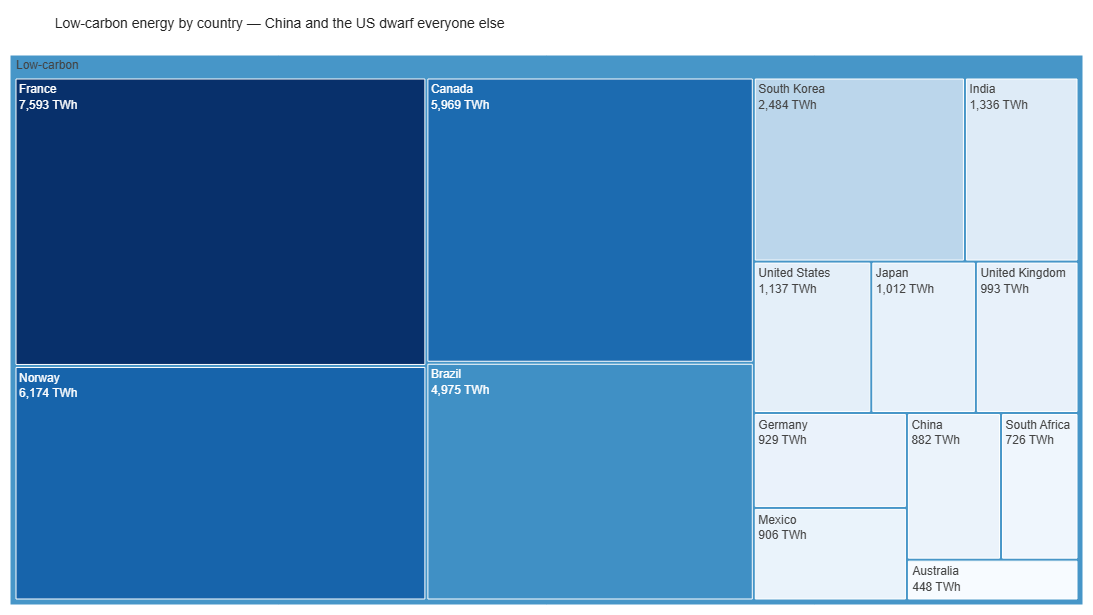

In [11]:
# Task 3 — charts
# YOUR CODE HERE

# Task 3: Treemap vs Bar — Low-Carbon Energy by Country
# -------------------------------------------------------

# Step 1: Filter and aggregate low-carbon TWh by country
lowcarbon = (
    df.loc[df['Source_Type'] == 'Low-carbon']
    .groupby('Country')['TWh']
    .sum()
    .reset_index()
    .sort_values('TWh', ascending=False)
)

# Add a dummy root node for single-level treemap
lowcarbon['All'] = 'Low-carbon'

print(f"Countries: {len(lowcarbon)}")
print(lowcarbon.head(10))

# ── Step 2a: TREEMAP ──────────────────────────────────────────────────────────
# Single-level path: dummy root 'Low-carbon' → Country
# Colour by TWh using a sequential blue scale (CVD-safe — lighter = less)

fig_tree = px.treemap(
    lowcarbon,
    path=['All', 'Country'],
    values='TWh',
    color='TWh',
    color_continuous_scale='Blues',     # sequential — CVD-safe
    labels={'TWh': 'Low-carbon Energy (TWh)'},
    title='Low-carbon energy by country — China and the US dwarf everyone else',
    height=600, width=1100
)

fig_tree.update_traces(
    texttemplate='%{label}<br>%{value:,.0f} TWh',
    hovertemplate='<b>%{label}</b><br>%{value:,.0f} TWh<extra></extra>',
    root_color='white',                 # root node ('Low-carbon') → white/invisible
)

fig_tree.update_layout(
    font=dict(family='Arial', size=12),
    margin=dict(l=10, r=10, t=55, b=10),
    paper_bgcolor='white',
    coloraxis_showscale=False,           # hide colour bar — TWh labels are sufficient
    title_font=dict(family='Arial', size=14, color='#222222'),
)

fig_tree.show()


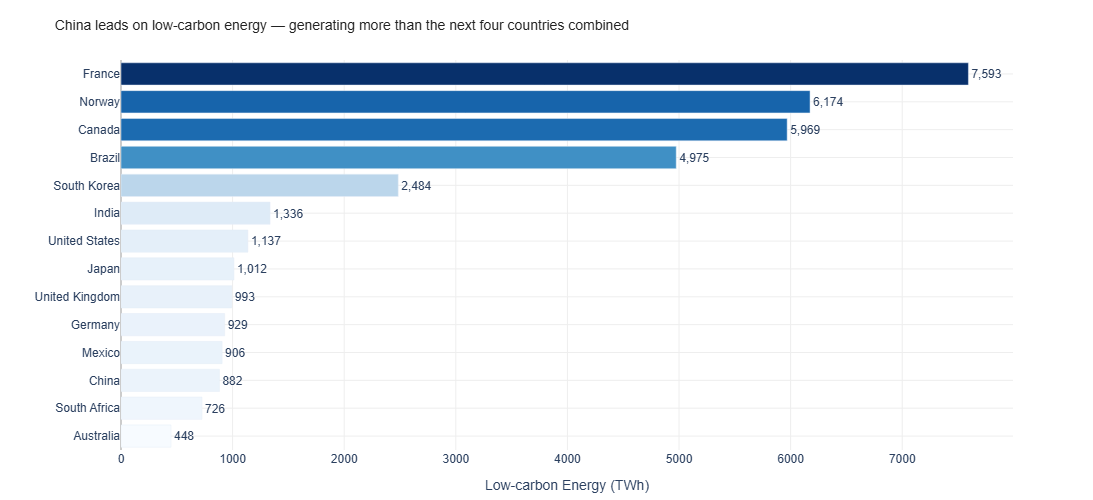

In [12]:
# ── Step 2b: HORIZONTAL BAR CHART ─────────────────────────────────────────────
# Sorted ascending so the longest bar (highest TWh) is at the top
# Colour: single CVD-safe blue for all bars (encoding is captured by bar length)

lowcarbon_sorted = lowcarbon.sort_values('TWh', ascending=True)  # ascending for horizontal bar

fig_bar = px.bar(
    lowcarbon_sorted,
    x='TWh',
    y='Country',
    orientation='h',
    color='TWh',
    color_continuous_scale='Blues',     # sequential CVD-safe scale
    labels={'TWh': 'Low-carbon Energy (TWh)', 'Country': ''},
    title='China leads on low-carbon energy — generating more than the next four countries combined',
    height=500, width=800
)

fig_bar.update_traces(
    texttemplate='%{x:,.0f}',
    textposition='outside',
    hovertemplate='<b>%{y}</b><br>%{x:,.0f} TWh<extra></extra>',
)

fig_bar.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    margin=dict(l=10, r=80, t=60, b=40),
    xaxis=dict(
        title='Low-carbon Energy (TWh)',
        gridcolor='#EEEEEE',
        zeroline=True,
        zerolinecolor='#CCCCCC',
        rangemode='tozero',              # zero baseline — mandatory rule
    ),
    yaxis=dict(gridcolor='#EEEEEE'),
    coloraxis_showscale=False,           # colour already encoded by bar length; scale is redundant
    title_font=dict(family='Arial', size=14, color='#222222'),
)

fig_bar.show()


In [ ]:
Which chart is better — and why?

The horizontal bar chart is better for this data.

The primary story here is ranking and magnitude comparison: which country produces the most low-carbon energy, and by how much? Bar length is the most accurate visual channel humans have for this task — we compare lengths along a shared baseline extremely well.

The treemap shows area, which is harder to compare precisely — it is useful when there are 15+ categories and the relative sizes (shares) matter more than the rank order. With a moderate number of countries and a clear "China leads" story, the bar chart communicates the gap far more directly.

Verdict: Use the bar chart. The treemap is visually interesting but sacrifices precision for aesthetics in this case.